<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  Target     45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


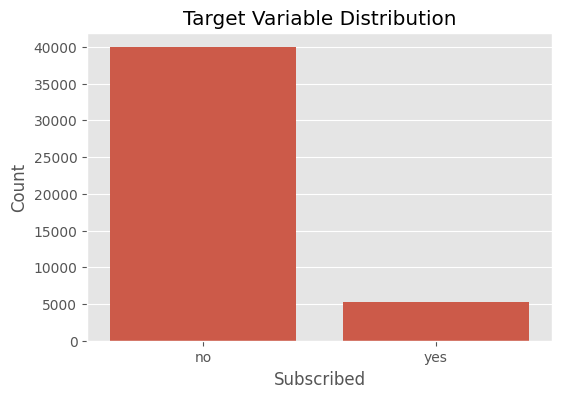

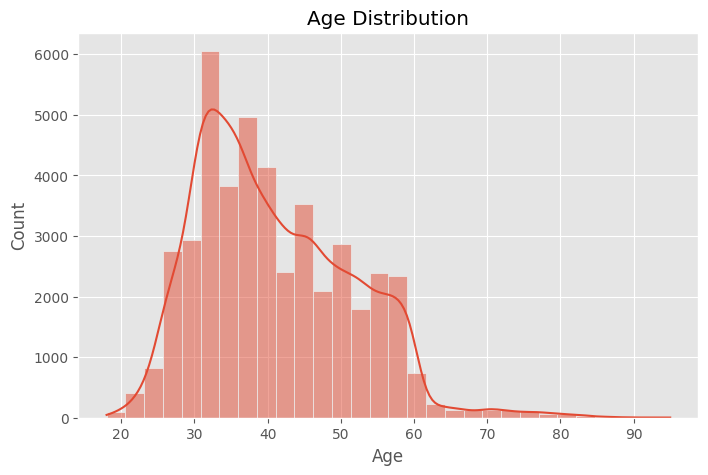

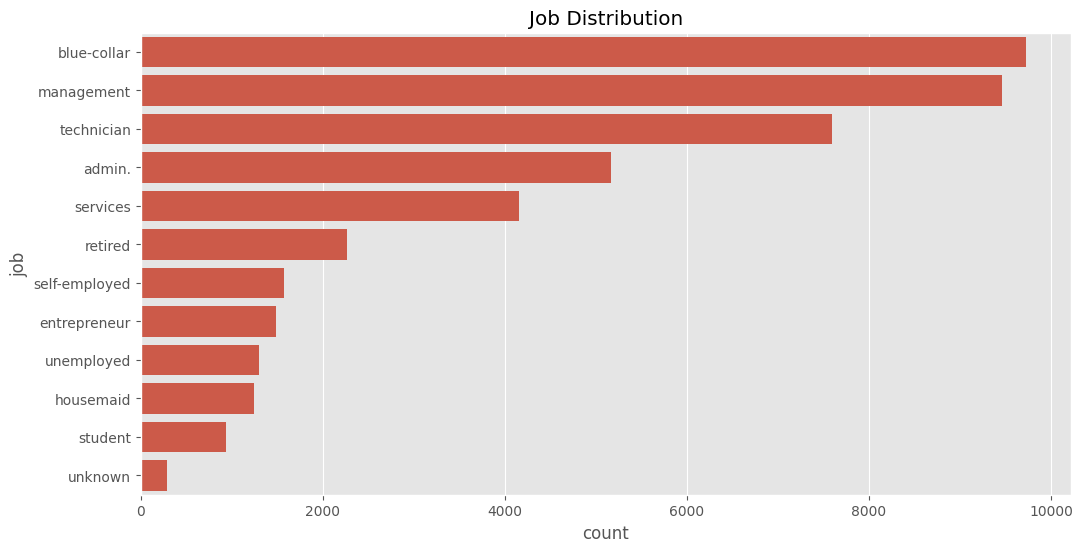

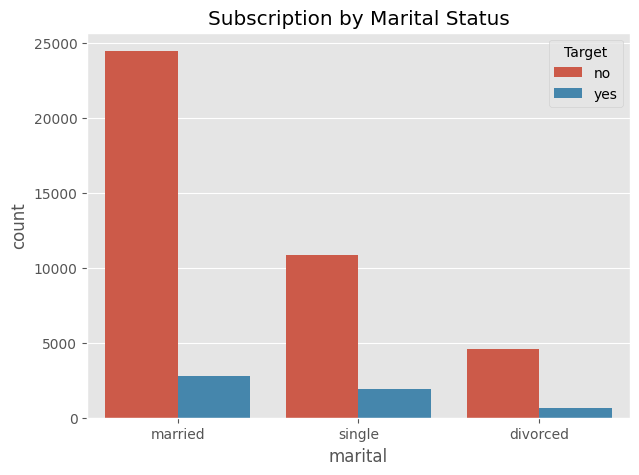

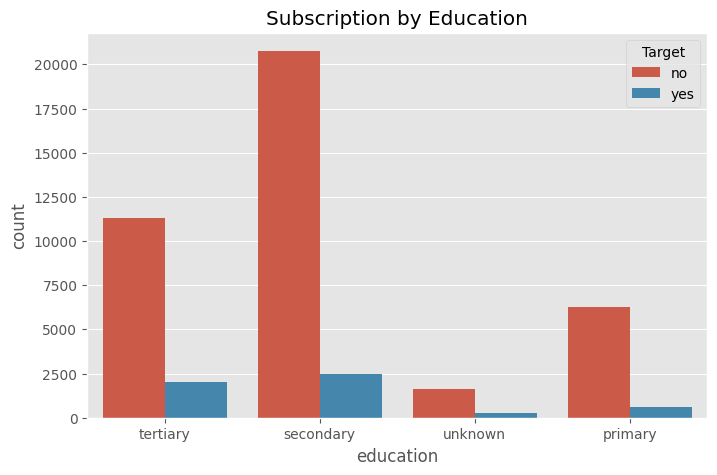

In [13]:
# =====================================================
# Task 3: Decision Tree Classification
# Prodigy InfoTech Data Science Internship
# =====================================================

# Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

plt.style.use("ggplot")
%matplotlib inline
# Load the dataset
df = pd.read_csv("bank-full.csv", sep=",")

# Display first five rows
df.head()
# Number of rows and columns
df.shape
# Column names
df.columns
# Dataset information
df.info()
# Statistical summary
df.describe()
# Missing values
df.isnull().sum()
# Duplicate rows
df.duplicated().sum()
# Count of customers who subscribed
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Target")
plt.title("Target Variable Distribution")
plt.xlabel("Subscribed")
plt.ylabel("Count")
plt.savefig("target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.savefig("age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="job",
    order=df["job"].value_counts().index
)

plt.title("Job Distribution")

plt.savefig("job_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="marital",
    hue="Target"
)

plt.title("Subscription by Marital Status")

plt.savefig("marital_subscription.png", dpi=300, bbox_inches="tight")
plt.show()
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="education",
    hue="Target"
)

plt.title("Subscription by Education")

plt.savefig("education_subscription.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
# Create a copy of the dataset
df_encoded = df.copy()

# Label Encoder
encoder = LabelEncoder()

# Encode all categorical columns
for column in df_encoded.columns:
    if df_encoded[column].dtype == "object":
        df_encoded[column] = encoder.fit_transform(df_encoded[column])

# Display first rows
df_encoded.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Target
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3,0
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3,0
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3,0
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3,0
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3,0


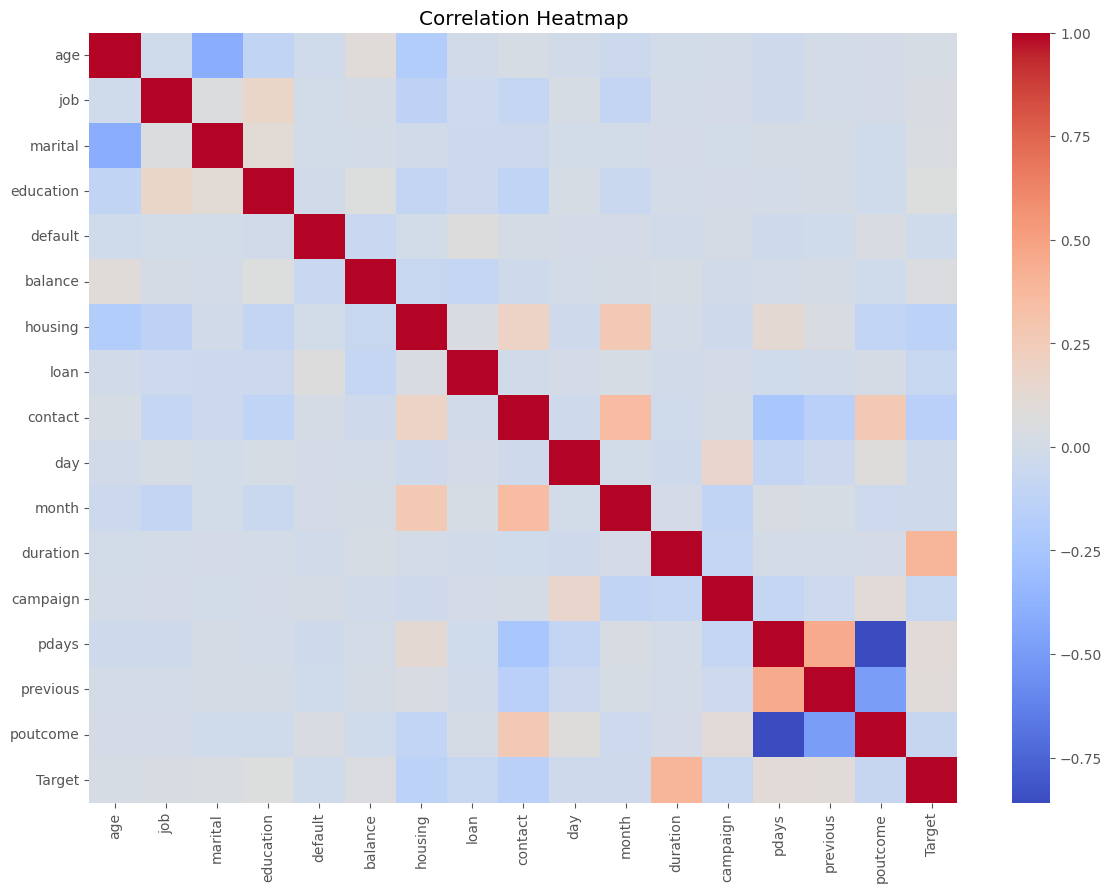

In [15]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df_encoded.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

Features shape: (45211, 16)
Target shape: (45211,)
Training data: (36168, 16)
Testing data: (9043, 16)
✅ Decision Tree Model Trained Successfully!
Predictions: [0 0 0 0 0 0 0 0 0 0]
Model Accuracy: 89.35%
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      7952
           1       0.59      0.40      0.48      1091

    accuracy                           0.89      9043
   macro avg       0.75      0.68      0.71      9043
weighted avg       0.88      0.89      0.88      9043



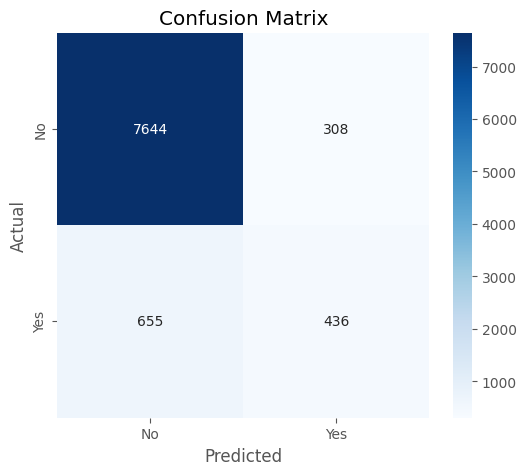

In [16]:
import pandas as pd

# Load the dataset
df = pd.read_csv("bank-full.csv", sep=",")

from sklearn.preprocessing import LabelEncoder

# Create a copy of the dataset
df_encoded = df.copy()

# Label Encoder
encoder = LabelEncoder()

# Encode all categorical columns
for column in df_encoded.columns:
    if df_encoded[column].dtype == "object":
        df_encoded[column] = encoder.fit_transform(df_encoded[column])

X = df_encoded.drop("Target", axis=1)
y = df_encoded["Target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
# Import Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

# Create the model
model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

print("✅ Decision Tree Model Trained Successfully!")
# Predict on test data
y_pred = model.predict(X_test)

# Display first 10 predictions
print("Predictions:", y_pred[:10])
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

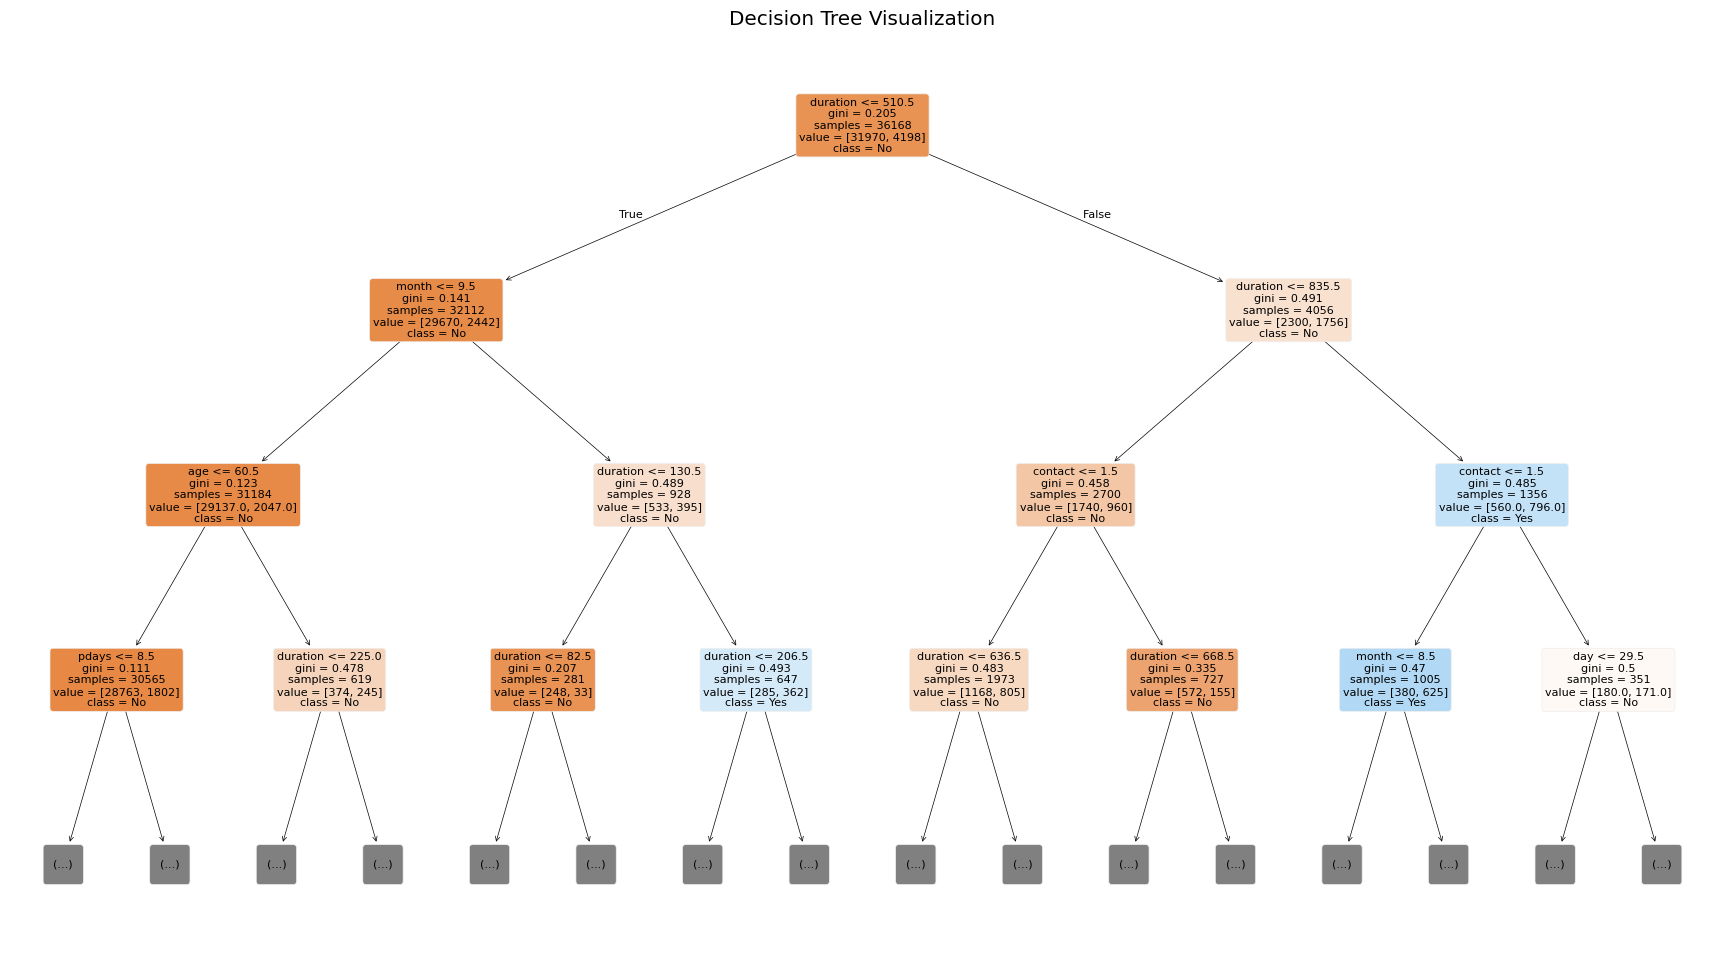

In [17]:
from sklearn.tree import plot_tree

plt.figure(figsize=(22,12))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No","Yes"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)

plt.title("Decision Tree Visualization")

plt.savefig("decision_tree.png", dpi=300, bbox_inches="tight")

plt.show()

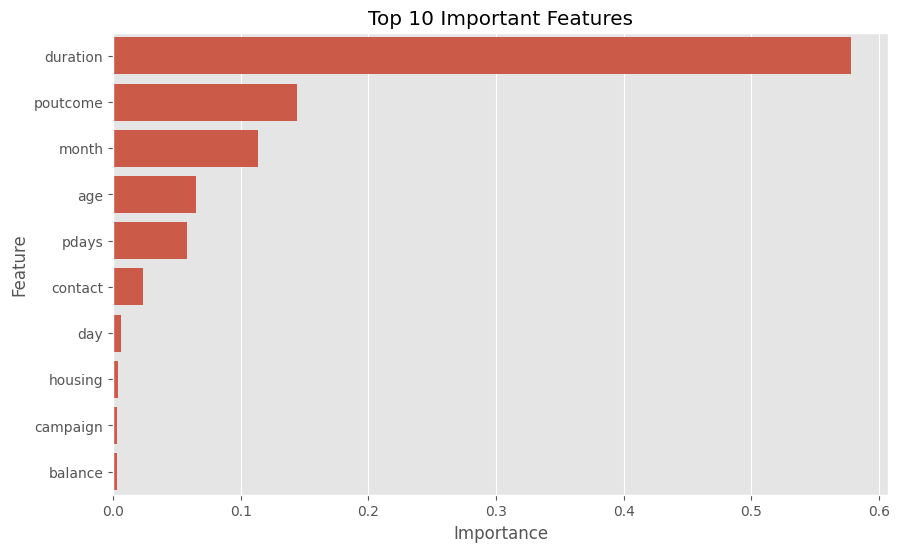

In [18]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()